📊 SIRD CALIBRATION (Phase 1)
✅ Loaded 369 data points from ../../NEW_PINN/real_datasets/covid-19_Kouprianov.csv
   Columns: ['t', 'I', 'D', 'S', 'R']

📊 Data info:
   Total points: 369
   Downsample step: 1 (using every 1-th point)

📊 Training data (downsampled):
   Original training points: 120
   Downsampled training points: 120 (every 1-th point)
   Training points ratio: 100.0% of original

🏥 Initial conditions (from first data point):
   Population: 6000000
   S0=5995513, I0=4197, R0=248, D0=42

🔧 Initial parameters: β=0.1133, γ=0.1000, μ=0.01000

🚀 Running optimization on DOWNSAMPLED training data (120 points)...

✅ Optimization successful!
   β = 0.121924
   γ = 0.099027
   μ = 0.009901
   R0 = 1.12
   Final loss (MSE on downsampled train): 453167.388585

📈 Running final simulation...

📊 Creating visualizations...


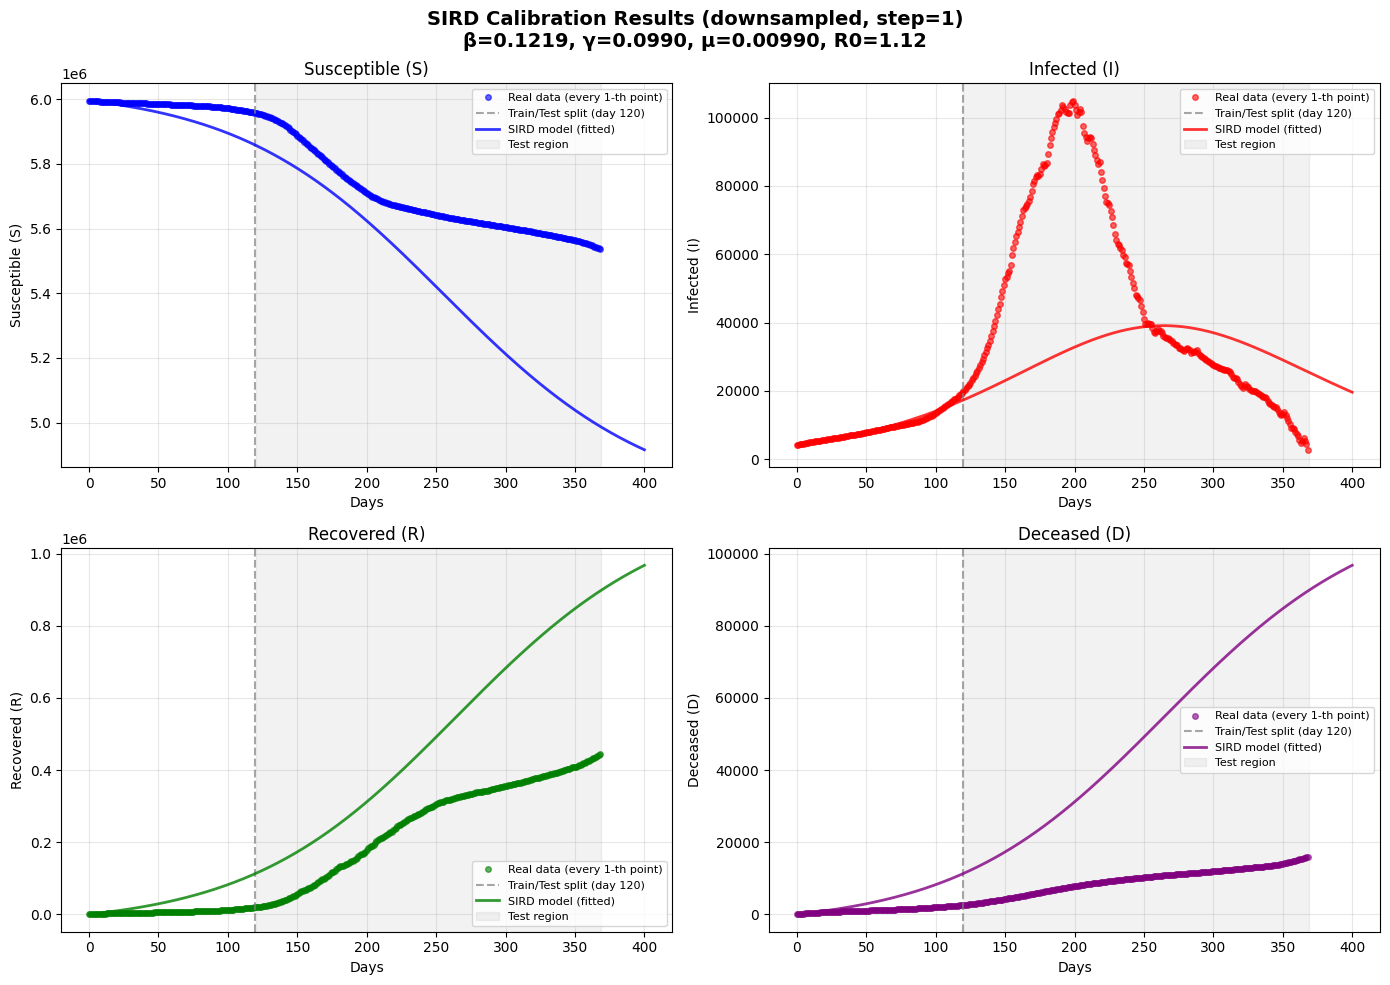

✅ Plot saved: calibration_results/sird_calibration_step1_20260516_235220.png
✅ Results saved: calibration_results/sird_calibration_step1_20260516_235220.json

📋 CALIBRATION SUMMARY

✅ Estimated parameters:
   β (infection rate): 0.121924
   γ (recovery rate): 0.099027
   μ (mortality rate): 0.009901
   R0 (basic reproduction): 1.12

📈 Peak prediction:
   Peak day: 264.3
   Peak height: 39086 infected

📊 Data usage:
   Original points: 369
   Downsample step: 1
   Points used for training: 120
   Points shown on plot: 369

📋 COPY THESE PARAMETERS FOR YOUR PIPELINE:

baseline_beta = 0.121924
baseline_gamma = 0.099027
baseline_mu = 0.009901
train_size = 120


In [10]:
"""
SIRD Calibration (Phase 1)
Подгоняет параметры SIRD модели к реальным данным.
Использует только каждую 7-ю точку для обучения (редуцированные данные).
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize
from datetime import datetime
import os
import json

# ============================================================
# 1. SIRD МОДЕЛЬ
# ============================================================

def sird_model(y, t, beta, gamma, mu, N):
    """SIRD модель для scipy"""
    S, I, R, D = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I - mu * I
    dRdt = gamma * I
    dDdt = mu * I
    return [dSdt, dIdt, dRdt, dDdt]

def simulate_sird(beta, gamma, mu, N, S0, I0, R0, D0, t_max, num_points=500):
    """Симуляция SIRD модели"""
    t = np.linspace(0, t_max, num_points)
    y0 = [S0, I0, R0, D0]
    
    solution = odeint(sird_model, y0, t, args=(beta, gamma, mu, N))
    S, I, R, D = solution.T
    
    return {
        't': t,
        'S': S,
        'I': I,
        'R': R,
        'D': D,
        'peak_position': t[np.argmax(I)],
        'peak_height': np.max(I)
    }

# ============================================================
# 2. ФУНКЦИЯ ДЛЯ РЕДУЦИРОВАНИЯ ДАННЫХ
# ============================================================

def downsample_data(data, step=7):
    """
    Берет каждую step-ю точку из данных.
    
    Args:
        data: массив данных
        step: шаг (по умолчанию 7)
    
    Returns:
        downsampled_data: редуцированные данные
        indices: индексы выбранных точек
    """
    indices = np.arange(0, len(data), step)
    return data[indices], indices

# ============================================================
# 3. ФУНКЦИЯ ПОТЕРЬ (на редуцированных данных)
# ============================================================

def loss_function(params, t_train, I_train, N, S0, I0, R0, D0, t_max, num_points=500):
    """
    Функция потерь: MSE только на обучающих данных (редуцированных)
    """
    beta, gamma, mu = params
    
    # Границы параметров
    if beta < 0 or beta > 1:
        return 1e10
    if gamma < 0 or gamma > 1:
        return 1e10
    if mu < 0 or mu > 1:
        return 1e10
    
    try:
        result = simulate_sird(beta, gamma, mu, N, S0, I0, R0, D0, t_max, num_points)
        I_pred = result['I']
        
        # Интерполируем предсказания на время обучения
        t_sim = result['t']
        I_pred_interp = np.interp(t_train, t_sim, I_pred)
        
        mse = np.mean((I_pred_interp - I_train) ** 2)
        return mse
    except:
        return 1e10


# ============================================================
# 4. ОСНОВНАЯ ФУНКЦИЯ КАЛИБРОВКИ
# ============================================================

def calibrate_sird(
    data_path: str,
    train_size: int = None,
    downsample_step: int = 1,  # ← НОВЫЙ ПАРАМЕТР (1 = все точки, 7 = каждую 7-ю)
    t_max: int = 200,
    num_points: int = 500,
    method: str = 'L-BFGS-B',
    verbose: bool = True
):
    """
    Калибровка SIRD модели на реальных данных.
    
    Args:
        data_path: путь к CSV файлу с колонками S, I, R, D
        train_size: количество первых точек для обучения (в ОРИГИНАЛЬНЫХ точках)
        downsample_step: брать каждую N-ю точку (1 = все, 7 = каждую 7-ю)
        t_max: максимальное время симуляции (дни)
        num_points: количество точек для симуляции
        method: метод оптимизации
        verbose: печатать ли прогресс
    """
    
    # 1. Загрузка данных
    print("=" * 60)
    print("📊 SIRD CALIBRATION (Phase 1)")
    print("=" * 60)
    
    df = pd.read_csv(data_path)
    print(f"✅ Loaded {len(df)} data points from {data_path}")
    print(f"   Columns: {list(df.columns)}")
    
    # Проверяем наличие колонок
    required_cols = ['S', 'I', 'R', 'D']
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found in {data_path}")
    
    # 2. Извлекаем ВСЕ данные
    S_all = df['S'].values
    I_all = df['I'].values
    R_all = df['R'].values
    D_all = df['D'].values
    
    total_points = len(S_all)
    t_all = np.arange(total_points)
    
    print(f"\n📊 Data info:")
    print(f"   Total points: {total_points}")
    print(f"   Downsample step: {downsample_step} (using every {downsample_step}-th point)")
    
    # 3. Редуцируем ВСЕ данные для отображения на графике (каждую 7-ю точку)
    if downsample_step > 1:
        display_indices = np.arange(0, total_points, downsample_step)
        S_display = S_all[display_indices]
        I_display = I_all[display_indices]
        R_display = R_all[display_indices]
        D_display = D_all[display_indices]
        t_display = t_all[display_indices]
        print(f"   Display points: {len(display_indices)} (every {downsample_step}-th point)")
    else:
        display_indices = np.arange(total_points)
        S_display = S_all
        I_display = I_all
        R_display = R_all
        D_display = D_all
        t_display = t_all
    
    # 4. Определяем train_size в ОРИГИНАЛЬНЫХ точках
    if train_size is None:
        train_size = total_points
    elif train_size > total_points:
        print(f"⚠️ train_size ({train_size}) > total points ({total_points}), using all data")
        train_size = total_points
    
    # 5. Для ОБУЧЕНИЯ берем редуцированные данные (каждую 7-ю точку)
    #    но только в пределах train_size
    train_indices = np.arange(0, train_size, downsample_step)
    I_train = I_all[train_indices]
    t_train = t_all[train_indices]
    
    print(f"\n📊 Training data (downsampled):")
    print(f"   Original training points: {train_size}")
    print(f"   Downsampled training points: {len(train_indices)} (every {downsample_step}-th point)")
    print(f"   Training points ratio: {len(train_indices)/train_size*100:.1f}% of original")
    
    # 6. Начальные условия (из первой точки ОРИГИНАЛЬНЫХ данных)
    population = float(S_all[0] + I_all[0] + R_all[0] + D_all[0])
    S0 = float(S_all[0])
    I0 = float(I_all[0])
    R0 = float(R_all[0])
    D0 = float(D_all[0])
    
    print(f"\n🏥 Initial conditions (from first data point):")
    print(f"   Population: {population:.0f}")
    print(f"   S0={S0:.0f}, I0={I0:.0f}, R0={R0:.0f}, D0={D0:.0f}")
    
    # 7. Начальное приближение для параметров
    if len(I_train) > 3:
        growth_rates = []
        for i in range(1, min(5, len(I_train))):
            if I_train[i-1] > 0:
                growth_rates.append(np.log(I_train[i] / I_train[i-1]))
        if growth_rates:
            avg_growth = np.mean(growth_rates)
            beta_init = max(0.1, min(0.8, avg_growth + 0.1))
        else:
            beta_init = 0.3
    else:
        beta_init = 0.3
    
    gamma_init = 0.1
    mu_init = 0.01
    
    init_params = [beta_init, gamma_init, mu_init]
    print(f"\n🔧 Initial parameters: β={beta_init:.4f}, γ={gamma_init:.4f}, μ={mu_init:.5f}")
    
    # 8. Оптимизация (на редуцированных train данных)
    print(f"\n🚀 Running optimization on DOWNSAMPLED training data ({len(train_indices)} points)...")
    
    bounds = [(0.01, 0.99), (0.001, 0.5), (0.0001, 0.1)]
    
    result = minimize(
        loss_function,
        init_params,
        args=(t_train, I_train, population, S0, I0, R0, D0, t_max, num_points),
        method=method,
        bounds=bounds,
        options={'maxiter': 1000, 'disp': verbose}
    )
    
    if result.success:
        beta_opt, gamma_opt, mu_opt = result.x
        print(f"\n✅ Optimization successful!")
        print(f"   β = {beta_opt:.6f}")
        print(f"   γ = {gamma_opt:.6f}")
        print(f"   μ = {mu_opt:.6f}")
        print(f"   R0 = {beta_opt / (gamma_opt + mu_opt):.2f}")
        print(f"   Final loss (MSE on downsampled train): {result.fun:.6f}")
    else:
        print(f"\n❌ Optimization failed: {result.message}")
        beta_opt, gamma_opt, mu_opt = init_params
    
    # 9. Финальная симуляция
    print(f"\n📈 Running final simulation...")
    final_sim = simulate_sird(beta_opt, gamma_opt, mu_opt, population, 
                               S0, I0, R0, D0, t_max, num_points)
    
    # 10. Визуализация (с редуцированными точками для отображения)
    print(f"\n📊 Creating visualizations...")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'SIRD Calibration Results (downsampled, step={downsample_step})\nβ={beta_opt:.4f}, γ={gamma_opt:.4f}, μ={mu_opt:.5f}, R0={beta_opt/(gamma_opt+mu_opt):.2f}',
                fontsize=14, fontweight='bold')
    
    compartments_data = [
        ('Susceptible (S)', axes[0, 0], S_display, final_sim['S'], 'blue'),
        ('Infected (I)', axes[0, 1], I_display, final_sim['I'], 'red'),
        ('Recovered (R)', axes[1, 0], R_display, final_sim['R'], 'green'),
        ('Deceased (D)', axes[1, 1], D_display, final_sim['D'], 'purple')
    ]
    
    for title, ax, data, pred, color in compartments_data:
        # Редуцированные точки для отображения
        ax.plot(t_display, data, 'o', ms=4, color=color, alpha=0.6, 
                label=f'Real data (every {downsample_step}-th point)')
        
        # Линия train/test split (в ОРИГИНАЛЬНЫХ днях)
        ax.axvline(train_size - 0.5, color='gray', linestyle='--', linewidth=1.5, 
                   alpha=0.7, label=f'Train/Test split (day {train_size})')
        
        # Предсказание SIRD
        ax.plot(final_sim['t'], pred, '-', linewidth=2, color=color, alpha=0.8, 
                label='SIRD model (fitted)')
        
        # Закрашиваем область test данных
        ax.axvspan(train_size, total_points, alpha=0.1, color='gray', label='Test region')
        
        ax.set_xlabel('Days')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Сохраняем график
    os.makedirs("calibration_results", exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plot_path = f"calibration_results/sird_calibration_step{downsample_step}_{timestamp}.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Plot saved: {plot_path}")
    
    # 11. Результаты
    results = {
        'success': result.success,
        'beta': float(beta_opt),
        'gamma': float(gamma_opt),
        'mu': float(mu_opt),
        'R0': float(beta_opt / (gamma_opt + mu_opt)),
        'final_loss': float(result.fun),
        'train_size_original': train_size,
        'train_size_downsampled': len(train_indices),
        'downsample_step': downsample_step,
        'total_points': total_points,
        'population': population,
        'initial_conditions': {
            'S0': float(S0), 'I0': float(I0), 'R0': float(R0), 'D0': float(D0)
        },
        'predictions': {
            't': final_sim['t'].tolist(),
            'S': final_sim['S'].tolist(),
            'I': final_sim['I'].tolist(),
            'R': final_sim['R'].tolist(),
            'D': final_sim['D'].tolist(),
            'peak_position': float(final_sim['peak_position']),
            'peak_height': float(final_sim['peak_height'])
        },
        'plot_path': plot_path
    }
    
    # Сохраняем JSON
    json_path = f"calibration_results/sird_calibration_step{downsample_step}_{timestamp}.json"
    
    def convert_to_serializable(obj):
        if hasattr(obj, 'tolist'):
            return obj.tolist()
        return obj
    
    results_json = {k: convert_to_serializable(v) for k, v in results.items() 
                    if k not in ['predictions']}
    results_json['predictions'] = {k: convert_to_serializable(v) 
                                    for k, v in results['predictions'].items()}
    
    with open(json_path, 'w') as f:
        json.dump(results_json, f, indent=2)
    print(f"✅ Results saved: {json_path}")
    
    # 12. Вывод итогов
    print("\n" + "=" * 60)
    print("📋 CALIBRATION SUMMARY")
    print("=" * 60)
    print(f"\n✅ Estimated parameters:")
    print(f"   β (infection rate): {beta_opt:.6f}")
    print(f"   γ (recovery rate): {gamma_opt:.6f}")
    print(f"   μ (mortality rate): {mu_opt:.6f}")
    print(f"   R0 (basic reproduction): {beta_opt/(gamma_opt+mu_opt):.2f}")
    
    print(f"\n📈 Peak prediction:")
    print(f"   Peak day: {final_sim['peak_position']:.1f}")
    print(f"   Peak height: {final_sim['peak_height']:.0f} infected")
    
    print(f"\n📊 Data usage:")
    print(f"   Original points: {total_points}")
    print(f"   Downsample step: {downsample_step}")
    print(f"   Points used for training: {len(train_indices)}")
    print(f"   Points shown on plot: {len(display_indices)}")
    
    print("\n" + "=" * 60)
    print("📋 COPY THESE PARAMETERS FOR YOUR PIPELINE:")
    print("=" * 60)
    print(f"\nbaseline_beta = {beta_opt:.6f}")
    print(f"baseline_gamma = {gamma_opt:.6f}")
    print(f"baseline_mu = {mu_opt:.6f}")
    print(f"train_size = {train_size}")
    
    return results


# ============================================================
# 5. ЗАПУСК КАЛИБРОВКИ
# ============================================================

if __name__ == "__main__":
    # 🔧 ИЗМЕНИ ПУТЬ К ТВОЕМУ ФАЙЛУ
    # DATA_PATH = "../../NEW_PINN/synthetic_datasets/01_baseline_constant.csv"
    DATA_PATH = "../../NEW_PINN/real_datasets/covid-19_Kouprianov.csv"
    # DATA_PATH = "../../NEW_PINN/real_datasets/PINN-COVID-Italy.csv"
    
    # Параметры калибровки
    TRAIN_SIZE = 120            # сколько первых ОРИГИНАЛЬНЫХ точек для обучения
    DOWNSAMPLE_STEP = 1         # ← 1 = все точки, 7 = каждую 7-ю точку
    T_MAX = 400                 # максимальное время симуляции
    NUM_POINTS = 1000           # количество точек в симуляции
    
    # Запуск
    results = calibrate_sird(
        data_path=DATA_PATH,
        train_size=TRAIN_SIZE,
        downsample_step=DOWNSAMPLE_STEP,  # ← новый параметр
        t_max=T_MAX,
        num_points=NUM_POINTS,
        method='L-BFGS-B',
        verbose=True
    )

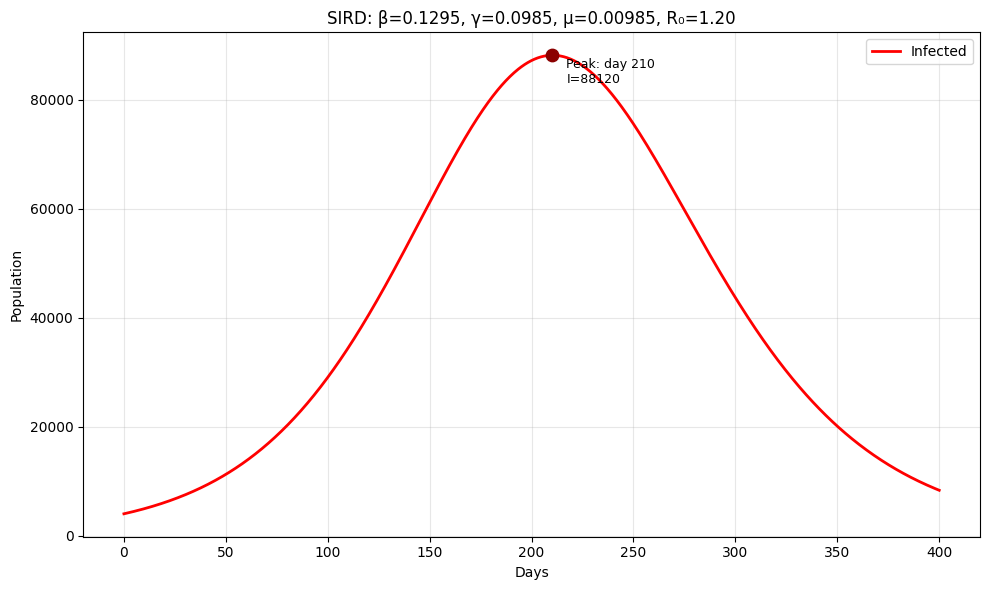

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def sird(y, t, beta, gamma, mu, N):
    S, I, R, D = y
    dS = -beta * S * I / N
    dI = beta * S * I / N - gamma * I - mu * I
    dR = gamma * I
    dD = mu * I
    return [dS, dI, dR, dD]

def plot_sird(beta, gamma, mu, N=10000, I0=100, t_max=400):
    S0 = N - I0
    t = np.linspace(0, t_max, 1000)
    sol = odeint(sird, [S0, I0, 0, 0], t, args=(beta, gamma, mu, N))
    S, I, R, D = sol.T
    
    plt.figure(figsize=(10, 6))
    plt.plot(t, I, 'r-', linewidth=2, label='Infected')
    # plt.plot(t, S, 'b-', linewidth=2, label='Susceptible')
    # plt.plot(t, R, 'g-', linewidth=2, label='Recovered')
    # plt.plot(t, D, 'purple', linewidth=2, label='Deceased')
    
    peak_idx = np.argmax(I)
    plt.scatter(t[peak_idx], I[peak_idx], color='darkred', s=80, zorder=5)
    plt.annotate(f'Peak: day {t[peak_idx]:.0f}\nI={I[peak_idx]:.0f}', 
                 xy=(t[peak_idx], I[peak_idx]), xytext=(10, -20),
                 textcoords='offset points', fontsize=9)
    
    plt.xlabel('Days')
    plt.ylabel('Population')
    plt.title(f'SIRD: β={beta}, γ={gamma}, μ={mu}, R₀={beta/(gamma+mu):.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Пример использования
plot_sird(beta=0.1295, gamma=0.0985, mu=0.00985, N = 6_000_000, I0=4000)